# ViralScope AI — Modular Pipeline

**Refactored architecture with clear class boundaries.**
Each major component is a class following the `ThumbnailManager` pattern.

| Class | Responsibility |
|-------|----------------|
| `ConfigLoader` | Load & validate config.yaml, create directories |
| `DataLoader` | Load CSVs, clean data, preserve dates |
| `LabelEngine` | LOO viral labels, buffer sampling, strategy preservation |
| `ThumbnailManager` | Download, validate, cache thumbnails |
| `EmbeddingExtractor` | SigLIP image/text embeddings + probe features |
| `DataSplitter` | Random stratified train/val/test splits |
| `TitleFeatureExtractor` | Power words, caps, punctuation features *(computed but intentionally excluded — introduced noise in ablation; kept for reproducibility)* |
| `VisualStatsExtractor` | Brightness, saturation, edge density |
| `FeatureBuilder` | Fuse embeddings + probes + visual → X_df |
| `StackingTrainer` | 5-fold OOF stacking ensemble training |
| `ModelEvaluator` | Threshold tuning, metrics, test set evaluation |
| `ModelPersistence` | Save/load models, results CSV |
| `ViralScopePipeline` | Orchestrator that ties all modules together |


## Cell 1 — Imports & Runtime Setup

Detects Colab vs local, sets working directory. All imports centralized here.
Global seeds are fixed for full reproducibility (seed = 42).

In [ ]:
import os
import sys
import re
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import threading
import time
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
from io import BytesIO

import cv2
import joblib
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn.functional as F
import yaml
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             f1_score, precision_recall_curve, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone as sklearn_clone
from tqdm.auto import tqdm
from transformers import SiglipModel, SiglipProcessor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from joblib import Parallel, delayed

# Runtime detection
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists('/content/ViralScope-AI'):
        import subprocess
        subprocess.run(['git', 'clone', 'https://github.com/yassine-cmd/ViralScope-AI.git',
                        '/content/ViralScope-AI'], check=True)
    sys.path.insert(0, '/content/ViralScope-AI')
    os.chdir('/content/ViralScope-AI')
else:
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

print(f'[Setup] Runtime     : {"Google Colab" if IN_COLAB else "Local"}')
print(f'[Setup] Working dir : {os.getcwd()}')

# ── Reproducibility: set all global seeds (Guide §4.3) ──────────────────────
import random
_GLOBAL_SEED = 42  # sync with config['project']['seed'] after Cell 2
random.seed(_GLOBAL_SEED)
np.random.seed(_GLOBAL_SEED)
torch.manual_seed(_GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(_GLOBAL_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f'[Setup] Global seed     : {_GLOBAL_SEED}')

[Setup] Runtime     : Google Colab
[Setup] Working dir : /content/ViralScope-AI
[Setup] Global seed     : 42


## Cell 2 — ConfigLoader Class

Single responsibility: load config.yaml, validate all required keys, create directories.
Fails loudly with clear error messages rather than silent failures.

In [ ]:
class ConfigLoader:
    """Load and validate configuration from config.yaml."""

    REQUIRED_KEYS = {
        'project': ['name', 'seed', 'device'],
        'data': ['raw_dir', 'processed_dir', 'tensor_dir', 'splits_dir',
                  'train_split', 'val_split', 'test_split',
                  'min_dataset_size', 'max_per_class', 'buffer_multiplier',
                  'target_threshold', 'sampling_strategy',
                  'thumbnail_url_template', 'thumbnail_fallback_url',
                  'thumbnail_rate_limit', 'thumbnail_download_workers'],
        'model': ['type', 'embedding'],
        'model.embedding': ['checkpoint', 'image_dim', 'text_dim', 'max_seq_length'],
        'paths': ['checkpoints', 'best_model', 'training_log', 'results'],
    }

    def __init__(self, config_path='config.yaml'):
        self.config_path = config_path
        self.config = None
        self.failed_video_ids = []  # Shared state for thumbnail failures

    def load(self):
        """Load config from YAML file."""
        if not os.path.exists(self.config_path):
            raise FileNotFoundError(
                f'{self.config_path} not found in {os.getcwd()}. '
                'Place config.yaml in the working directory before continuing.')
        with open(self.config_path) as f:
            self.config = yaml.safe_load(f)
        if not self.config:
            raise ValueError('config.yaml is empty — provide a valid configuration file.')
        return self

    def validate(self):
        """Validate all required keys are present. Raises KeyError with details if missing."""
        missing = []
        for section, keys in self.REQUIRED_KEYS.items():
            if '.' in section:
                top, sub = section.split('.', 1)
                node = self.config.get(top, {}).get(sub)
                if node is None:
                    missing.append(f"  CONFIG['{top}']['{sub}'] block is missing")
                    continue
                for key in keys:
                    if key not in node:
                        missing.append(f"  CONFIG['{top}']['{sub}']['{key}'] is missing")
            else:
                if section not in self.config:
                    missing.append(f"  CONFIG['{section}'] block is missing")
                    continue
                for key in keys:
                    if key not in self.config[section]:
                        missing.append(f"  CONFIG['{section}']['{key}'] is missing")
        if missing:
            raise KeyError('Config validation failed — missing keys:\n' + '\n'.join(missing))
        return self

    def create_directories(self):
        """Create all required output directories."""
        dirs = [
            self.config['data']['raw_dir'],
            f"{self.config['data']['raw_dir']}/thumbnails",
            self.config['data']['processed_dir'],
            self.config['data']['tensor_dir'],
            self.config['data']['splits_dir'],
            self.config['paths']['checkpoints'],
            self.config['paths']['results'],
            os.path.dirname(self.config['paths']['best_model']),
            os.path.dirname(self.config['paths']['training_log']),
        ]
        for d in dirs:
            os.makedirs(d, exist_ok=True)
        return self

    def print_summary(self):
        """Print configuration summary."""
        cfg = self.config
        print(f'[Config] Loaded and validated : {self.config_path}')
        print(f'[Config] Project              : {cfg["project"]["name"]}')
        print(f'[Config] Seed                 : {cfg["project"]["seed"]}')
        print(f'[Config] Backbone             : {cfg["model"]["embedding"]["checkpoint"]}')
        print(f'[Config] Embedding dims       : img={cfg["model"]["embedding"]["image_dim"]}  '
              f'txt={cfg["model"]["embedding"]["text_dim"]}')
        print(f'[Config] max_per_class        : {cfg["data"].get("max_per_class", 999999):,}')
        print(f'[Config] sampling_strategy    : {cfg["data"]["sampling_strategy"]}')
        return self


# Initialize config
loader = ConfigLoader('config.yaml')
loader.load().validate().create_directories().print_summary()
CONFIG = loader.config


[Config] Loaded and validated : config.yaml
[Config] Project              : ViralScope AI V2
[Config] Seed                 : 42
[Config] Backbone             : google/siglip-base-patch16-224
[Config] Embedding dims       : img=768  txt=768
[Config] max_per_class        : 999,999
[Config] sampling_strategy    : balanced


## Cell 3 — DataLoader Class

Handles CSV loading, combining multiple market files, and data cleaning.
Preserves date columns and extracts time-based features. Warns on non-English market files since the SigLIP text encoder is English-only.

In [ ]:
class DataLoader:
    """Load, combine, and clean YouTube trending CSV files."""

    ENGLISH_MARKETS = {'US', 'GB', 'CA'}

    def __init__(self, config):
        self.config = config
        self.raw_dir = config['data']['raw_dir']
        self.processed_dir = config['data']['processed_dir']
        self.clean_df = None
        self.labeled_df = None

    def find_csv_files(self):
        """Find CSV files in raw directory, excluding trending.csv."""
        csv_files = [f for f in os.listdir(self.raw_dir)
                    if f.endswith('.csv') and f != 'trending.csv']

        if not csv_files:
            print(f'[Data] No CSV files found in {self.raw_dir}.')
            if IN_COLAB:
                from google.colab import files as _cf
                uploaded = _cf.upload()
                for fname, content in uploaded.items():
                    with open(os.path.join(self.raw_dir, fname), 'wb') as fh:
                        fh.write(content)
                    print(f'[Data] Saved: {fname}')
                csv_files = [f for f in os.listdir(self.raw_dir)
                             if f.endswith('.csv') and f != 'trending.csv']
            else:
                raise FileNotFoundError(
                    f'Place CSVs in {os.path.abspath(self.raw_dir)} and re-run.')

        # Warn about non-English markets
        detected = {f.replace('videos.csv', '').replace('videos', '') for f in csv_files}
        non_en = detected - self.ENGLISH_MARKETS
        if non_en:
            print(f'[Data] WARNING: non-English market files detected: {non_en}')
            print('[Data]          SigLIP text encoder is English-only — accuracy may degrade.')

        print(f'[Data] Found {len(csv_files)} CSV file(s): {csv_files}')
        return csv_files

    def load_and_clean(self):
        """Load all CSVs, combine, and clean."""
        csv_files = self.find_csv_files()

        print(f'[Data] Loading {len(csv_files)} CSV file(s)...')
        all_dfs = []
        for csv_file in csv_files:
            try:
                df = pd.read_csv(os.path.join(self.raw_dir, csv_file),
                                  on_bad_lines='skip', low_memory=False, encoding='utf-8')
                if 'video_id' not in df.columns and 'id' in df.columns:
                    df = df.rename(columns={'id': 'video_id'})
                all_dfs.append(df)
                print(f'[Data]   {csv_file}: {len(df):,} rows')
            except Exception as e:
                print(f'[Data]   ERROR loading {csv_file}: {e}')

        if not all_dfs:
            raise ValueError('[Data] No data loaded — verify CSV files are valid and non-empty.')

        trending_df = pd.concat(all_dfs, ignore_index=True)
        trending_df.to_csv(f'{self.raw_dir}/trending.csv', index=False)
        print(f'[Data] Combined total : {len(trending_df):,} rows')

        self.clean_df = self._clean_dataset(trending_df)
        self.clean_df.to_csv(f'{self.processed_dir}/clean_dataset.csv', index=False)
        print(f'[Data] After cleaning : {len(self.clean_df):,} rows  ->  saved clean_dataset.csv')
        return self

    def _clean_dataset(self, df):
        """Deduplicate, drop invalid rows, retain required columns + date."""
        if 'video_id' in df.columns:
            df = df.dropna(subset=['video_id'])
            df = df[df['video_id'].astype(str).str.strip() != '']
        if 'views' in df.columns:
            df['views'] = pd.to_numeric(df['views'], errors='coerce')
            df = df.dropna(subset=['views'])
            df = df[df['views'] > 0]
        if 'channel_id' not in df.columns:
            df['channel_id'] = (df['channel_title'].astype(str)
                                if 'channel_title' in df.columns else 'unknown')
        if 'title' not in df.columns:
            df['title'] = 'Untitled'
        else:
            df['title'] = df['title'].fillna('Untitled').astype(str)
            df = df[df['title'].str.strip() != '']
        if 'video_id' in df.columns:
            df = df.drop_duplicates(subset=['video_id'], keep='last')

        # Preserve dates for time-based splitting
        if 'trending_date' in df.columns:
            date_col = 'trending_date'
        elif 'publishedAt' in df.columns:
            date_col = 'publishedAt'
        else:
            df['trending_date'] = '1970-01-01'
            date_col = 'trending_date'

        df['trending_date'] = pd.to_datetime(df[date_col], format='mixed', errors='coerce')

        # Context features
        if 'category_id' in df.columns:
            df['category_id'] = pd.to_numeric(df['category_id'], errors='coerce').fillna(0).astype(int)
        else:
            df['category_id'] = 0

        if 'trending_date' in df.columns:
            df['hour_of_day'] = df['trending_date'].dt.hour.fillna(12).astype(int)
            df['day_of_week'] = df['trending_date'].dt.dayofweek.fillna(3).astype(int)
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
        else:
            df['hour_of_day'] = 12
            df['day_of_week'] = 3
            df['is_weekend'] = 0

        keep = ['video_id', 'title', 'views', 'channel_title', 'channel_id',
                'trending_date', 'category_id', 'hour_of_day', 'day_of_week', 'is_weekend']
        return df[[c for c in keep if c in df.columns]].reset_index(drop=True)


# Initialize and load data
data_loader = DataLoader(CONFIG)
data_loader.load_and_clean()
clean_df = data_loader.clean_df


[Data] Found 3 CSV file(s): ['CAvideos.csv', 'GBvideos.csv', 'USvideos.csv']
[Data] Loading 3 CSV file(s)...
[Data]   CAvideos.csv: 40,881 rows
[Data]   GBvideos.csv: 38,916 rows
[Data]   USvideos.csv: 40,949 rows
[Data] Combined total : 120,746 rows
[Data] After cleaning : 30,318 rows  ->  saved clean_dataset.csv


## Cell 4 — LabelEngine Class

Computes Leave-One-Out (LOO) viral labels to prevent data leakage.
Handles buffer sampling and strategy preservation (`balanced` / `imbalanced` / `all`).
Raises an error if class imbalance falls below 10%.

In [ ]:
class LabelEngine:
    """Compute LOO viral labels with proper train/test leakage prevention."""

    def __init__(self, config):
        self.config = config
        self.seed = config['project']['seed']
        self.labeled_df = None

    def compute_labels(self, df, train_idx=None):
        """LOO viral labelling — train-only stats to prevent leakage.

        When train_idx is supplied, channel means are computed from
        training rows only. Val/test rows use the plain training mean.
        When called without train_idx, all rows act as training data.
        """
        df_for_stats = df.iloc[train_idx].copy() if train_idx is not None else df.copy()
        train_stats = (df_for_stats.groupby('channel_id')['views']
                         .agg(['sum', 'count', 'mean']).reset_index())
        train_stats.columns = ['channel_id', 'channel_sum', 'video_count', 'channel_avg']
        global_mean = df_for_stats['views'].mean()

        result = df.merge(train_stats, on='channel_id', how='left').reset_index(drop=True)

        is_train = (result.index.isin(train_idx)
                     if train_idx is not None
                     else pd.Series([True] * len(result), index=result.index))

        result['channel_ref_views'] = global_mean
        reliable = result['video_count'].fillna(0) >= 2

        # Train rows: LOO mean
        loo = is_train & reliable
        result.loc[loo, 'channel_ref_views'] = (
            (result.loc[loo, 'channel_sum'] - result.loc[loo, 'views']) /
            (result.loc[loo, 'video_count'] - 1).clip(lower=1))

        # Val/test rows: plain training mean
        vt = (~is_train) & reliable
        result.loc[vt, 'channel_ref_views'] = result.loc[vt, 'channel_avg']

        result['multiplier'] = result['views'] / (result['channel_ref_views'] + 1e-5)
        result['log_multiplier'] = np.log1p(result['multiplier'])
        thresh = self.config['data']['target_threshold']
        result['is_viral'] = (result['multiplier'] > thresh).astype(float)

        # Check class balance
        minority = min(result['is_viral'].mean(), 1 - result['is_viral'].mean())
        if minority < 0.10:
            raise ValueError(
                '[Labels] Class imbalance < 10% detected. '
                'Update config.yaml: set target_threshold explicitly (e.g., 1.2) '
                'or increase max_per_class to improve label balance.')

        cols = ['video_id', 'title', 'views', 'channel_ref_views',
                'multiplier', 'is_viral', 'channel_id',
                'category_id', 'hour_of_day', 'day_of_week', 'is_weekend']
        return result[[c for c in cols if c in result.columns]].reset_index(drop=True)

    def apply_sampling_strategy(self, df, buffer=False):
        """Apply sampling strategy from config: balanced/imbalanced/all."""
        strategy = self.config['data'].get('sampling_strategy', 'imbalanced')

        if strategy == 'all':
            df = df.sample(frac=1, random_state=self.seed).reset_index(drop=True)
            print(f'[Labels] Strategy: "all" | Total rows: {len(df):,}')
            return df

        if strategy == 'imbalanced':
            viral_df = df[df['is_viral'] == 1].copy()
            viral_channels = viral_df['channel_id'].unique()
            neg_ratio = self.config['data'].get('negative_ratio', 3)

            potential_hard_negs = df[(df['is_viral'] == 0) & (df['channel_id'].isin(viral_channels))].copy()
            other_negs = df[(df['is_viral'] == 0) & (~df['channel_id'].isin(viral_channels))].copy()

            n_neg_needed = int(len(viral_df) * neg_ratio)
            hard_negatives = potential_hard_negs.sample(n=min(len(potential_hard_negs), n_neg_needed), random_state=self.seed)
            remaining = max(0, n_neg_needed - len(hard_negatives))

            if remaining > 0 and len(other_negs) > 0:
                fill = other_negs.sample(n=min(remaining, len(other_negs)), random_state=self.seed)
                neg_samples = pd.concat([hard_negatives, fill])
            else:
                neg_samples = hard_negatives

            if len(neg_samples) < n_neg_needed:
                print(f'[Labels] WARNING: only {len(neg_samples):,} non-viral samples available for target ratio {neg_ratio}.')

            neg_samples = neg_samples.sample(n=min(len(neg_samples), n_neg_needed), random_state=self.seed)
            df = pd.concat([viral_df, neg_samples]).sample(frac=1, random_state=self.seed).reset_index(drop=True)
            print(f'[Labels] Strategy: "Hard Negatives" | Viral: {len(viral_df):,} | Non-Viral: {len(neg_samples):,}')
            return df

        # Balanced strategy
        if buffer:
            max_per_class = int(self.config['data'].get('max_per_class', 1000) *
                              self.config['data'].get('buffer_multiplier', 1.5))
        else:
            max_per_class = self.config['data'].get('max_per_class', 1000)

        viral_df = df[df['is_viral'] == 1]
        nonviral_df = df[df['is_viral'] == 0]
        n_available = min(max_per_class, len(viral_df), len(nonviral_df))

        if n_available < max_per_class:
            print(f'[Labels] WARNING: only {n_available:,}/class available (target {max_per_class:,}).')

        df = pd.concat([
            viral_df.sample(n=n_available, random_state=self.seed),
            nonviral_df.sample(n=n_available, random_state=self.seed),
        ]).sample(frac=1, random_state=self.seed).reset_index(drop=True)

        print(f'[Labels] Strategy: "balanced" | {n_available:,}/class x 2 = {len(df):,} rows')
        return df

    def fit_transform(self, df, buffer=True):
        """Full labeling pipeline: compute labels then apply sampling."""
        self.labeled_df = self.compute_labels(df)
        print(f'[Labels] Full dataset labelled: {len(self.labeled_df):,} rows')
        print(f'[Labels]   Viral     : {int(self.labeled_df["is_viral"].sum()):,}')
        print(f'[Labels]   Non-viral : {int((self.labeled_df["is_viral"]==0).sum()):,}')

        self.labeled_df = self.apply_sampling_strategy(self.labeled_df, buffer=buffer)

        # Save intermediate
        self.labeled_df.to_csv(f"{self.config['data']['processed_dir']}/labeled_dataset.csv", index=False)
        print('[Labels] Saved labeled_dataset.csv')
        return self.labeled_df


# Initialize label engine
label_engine = LabelEngine(CONFIG)
labeled_df = label_engine.fit_transform(clean_df, buffer=True)


[Labels] Full dataset labelled: 30,318 rows
[Labels]   Viral     : 7,896
[Labels]   Non-viral : 22,422
[Labels] WARNING: only 7,896/class available (target 1,499,998).
[Labels] Strategy: "balanced" | 7,896/class x 2 = 15,792 rows
[Labels] Saved labeled_dataset.csv


## Cell 5 — ThumbnailManager Class

Single responsibility: manage the full thumbnail lifecycle.
Download, validate, resize, and serve images. Rate-limited and parallelized via `ThreadPoolExecutor`.

In [ ]:
class ThumbnailManager:
    """Centralized thumbnail management - single source of truth for all thumbnail operations."""

    def __init__(self, config, target_size=(224, 224), min_size=(120, 80)):
        self.thumb_dir = f"{config['data']['raw_dir']}/thumbnails"
        self.template = config['data']['thumbnail_url_template']
        self.fallback = config['data']['thumbnail_fallback_url']
        self.workers = config['data']['thumbnail_download_workers']
        self.rate_limit = config['data'].get('thumbnail_rate_limit', 10)
        self.target_size = target_size
        self.min_size = min_size
        self.lock = threading.Lock()
        self.last_t = 0.0
        os.makedirs(self.thumb_dir, exist_ok=True)

    def _rate_limit_wait(self):
        min_gap = 1.0 / self.rate_limit if self.rate_limit > 0 else 0
        with self.lock:
            now = time.time()
            wait = min_gap - (now - self.last_t)
            if wait < 0: wait = 0.0
        if wait > 0: time.sleep(wait)
        with self.lock:
            self.last_t = time.time()

    def _download_one(self, vid):
        self._rate_limit_wait()
        path = os.path.join(self.thumb_dir, f'{vid}.jpg')
        if os.path.exists(path):
            try:
                img = Image.open(path)
                img.verify()
                if img.size == self.target_size:
                    return vid, 'exists'
                img.close()
                os.remove(path)
            except Exception:
                try: os.remove(path)
                except Exception: pass
        try:
            r = requests.get(self.template.format(video_id=vid), timeout=5)
            if r.status_code != 200:
                r = requests.get(self.fallback.format(video_id=vid), timeout=5)
            if r.status_code == 200:
                img = Image.open(BytesIO(r.content))
                if img.size[0] < self.min_size[0] or img.size[1] < self.min_size[1]:
                    return vid, False
                img = img.resize(self.target_size, Image.Resampling.LANCZOS)
                img.save(path, quality=95)
                img = Image.open(path)
                img.verify()
                return vid, True
        except Exception:
            pass
        return vid, False

    def download(self, video_ids, desc='Thumbnails'):
        ok = fail = skip = 0
        failed = []
        with ThreadPoolExecutor(max_workers=self.workers) as pool:
            futs = {pool.submit(self._download_one, v): v for v in video_ids}
            for fut in tqdm(as_completed(futs), total=len(video_ids), desc=desc):
                vid, status = fut.result()
                if status is True: ok += 1
                elif status is False: fail += 1; failed.append(vid)
                else: skip += 1
        print(f'[Thumbnails] OK: {ok:,}  |  Failed: {fail:,}  |  Cached: {skip:,}')
        return failed

    def get_valid(self, video_ids):
        valid = []
        missing = []
        for vid in video_ids:
            path = os.path.join(self.thumb_dir, f'{vid}.jpg')
            try:
                img = Image.open(path)
                img.verify()
                valid.append(vid)
            except Exception:
                missing.append(vid)
        return valid, missing

    def load_image(self, video_id):
        path = os.path.join(self.thumb_dir, f'{video_id}.jpg')
        return Image.open(path).convert('RGB')


# Initialize ThumbnailManager
TM = ThumbnailManager(CONFIG)
failed_video_ids = TM.download(labeled_df['video_id'].tolist())
loader.failed_video_ids = failed_video_ids  # Share state


Thumbnails:   0%|          | 0/15792 [00:00<?, ?it/s]

[Thumbnails] OK: 12,108  |  Failed: 3,684  |  Cached: 0


## Cell 6 — Apply Sampling Strategy After Thumbnail Download

Remove rows whose thumbnails failed to download, then re-apply the balanced cap.
This ensures every row in the dataset has a valid image before embedding extraction.

In [ ]:
# Remove rows with failed thumbnail downloads
labeled_df = labeled_df[
    ~labeled_df['video_id'].isin(failed_video_ids)
].reset_index(drop=True)
print(f'[Cap] Rows after removing {len(failed_video_ids):,} failed thumbnails: {len(labeled_df):,}')

# Re-apply balanced cap after thumbnail failures
strategy = CONFIG['data'].get('sampling_strategy', 'balanced')

if strategy == 'balanced':
    max_per_class = CONFIG['data'].get('max_per_class', 999999)
    viral_df = labeled_df[labeled_df['is_viral'] == 1]
    nonviral_df = labeled_df[labeled_df['is_viral'] == 0]
    n_final = min(max_per_class, len(viral_df), len(nonviral_df))

    if n_final < max_per_class:
        print(f'[Cap] WARNING: only {n_final:,}/class available (target {max_per_class:,}).')

    labeled_df = pd.concat([
        viral_df.sample(n=n_final, random_state=CONFIG['project']['seed']),
        nonviral_df.sample(n=n_final, random_state=CONFIG['project']['seed']),
    ]).sample(frac=1, random_state=CONFIG['project']['seed']).reset_index(drop=True)

    print(f'[Cap] Final dataset : {n_final:,} viral + {n_final:,} non-viral = {len(labeled_df):,} total')
else:
    print(f'[Cap] Strategy is "{strategy}" — no balanced capping applied.')

# Shuffle before random stratified splits
labeled_df = labeled_df.sample(frac=1, random_state=CONFIG['project']['seed']).reset_index(drop=True)
print('[Cap] Dataset shuffled.')

labeled_df.to_csv(f"{CONFIG['data']['processed_dir']}/labeled_dataset.csv", index=False)
print('[Cap] Saved labeled_dataset.csv')


[Cap] Rows after removing 3,684 failed thumbnails: 12,108
[Cap] WARNING: only 6,031/class available (target 999,999).
[Cap] Final dataset : 6,031 viral + 6,031 non-viral = 12,062 total
[Cap] Dataset shuffled.
[Cap] Saved labeled_dataset.csv


## Cell 7 — EmbeddingExtractor Class

Extracts SigLIP image/text embeddings and zero-shot probe features.
Results are cached to disk (`force_recompute=False` by default). Uses `ThumbnailManager` as the single source of truth for image loading.
SigLIP is unloaded from memory after extraction — subsequent steps run on CPU.

In [ ]:
class EmbeddingExtractor:
    """Extract SigLIP embeddings and probe features, with disk caching."""

    PROBE_PAIRS = [
        ("a shocking or surprising YouTube thumbnail", "a boring and unremarkable thumbnail"),
        ("a face with exaggerated emotional expression", "a thumbnail with no human faces"),
        ("a thumbnail with bold text overlay bright colors", "a clean minimal thumbnail with no text"),
        ("a before and after transformation image", "an ordinary everyday single image"),
        ("a curious mysterious image that makes you click", "a clear simple informational image"),
        ("a high production value professional thumbnail", "a low quality amateur thumbnail"),
    ]

    def __init__(self, config, thumbnail_manager):
        self.config = config
        self.tm = thumbnail_manager
        self.tensor_dir = config['data']['tensor_dir']
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.batch_size = 32
        self.img_dim = config['model']['embedding']['image_dim']
        self.txt_dim = config['model']['embedding']['text_dim']
        self.max_seq_length = config['model']['embedding'].get('max_seq_length', 64)
        self.n_probes = len(self.PROBE_PAIRS)

        # Paths
        self.img_path = f'{self.tensor_dir}/img_embeddings.npy'
        self.txt_path = f'{self.tensor_dir}/txt_embeddings.npy'
        self.probe_path = f'{self.tensor_dir}/probe_features.npy'
        self.ids_path = f'{self.tensor_dir}/video_ids.npy'

    def _to_tensor(self, output):
        """Safely extract tensor from model output."""
        if isinstance(output, torch.Tensor):
            return output
        if hasattr(output, 'pooler_output') and output.pooler_output is not None:
            return output.pooler_output
        if hasattr(output, 'last_hidden_state'):
            return output.last_hidden_state[:, 0]
        raise TypeError(f'Cannot extract embedding tensor from {type(output)}')

    def extract(self, df, force_recompute=False):
        """Extract embeddings. Load from cache if available unless force_recompute."""
        if (not force_recompute and
            os.path.exists(self.img_path) and
            os.path.exists(self.txt_path) and
            os.path.exists(self.probe_path) and
            os.path.exists(self.ids_path)):

            cached_img = np.load(self.img_path)
            cached_txt = np.load(self.txt_path)
            cached_probe = np.load(self.probe_path)
            cached_ids = np.load(self.ids_path, allow_pickle=True).astype(str)

            # Map cached IDs to their row index
            id_to_idx = {vid: idx for idx, vid in enumerate(cached_ids)}

            # Fetch the correct rows in the EXACT order of the current df
            indices = []
            for vid in df['video_id']:
                if vid in id_to_idx:
                    indices.append(id_to_idx[vid])

            if indices:
                print(f'[Embed] Loaded {len(indices)} aligned embeddings from cache.')
                return cached_img[indices], cached_txt[indices], cached_probe[indices]

        # Load SigLIP
        checkpoint = self.config['model']['embedding']['checkpoint']
        print(f'[Embed] Loading SigLIP : {checkpoint}')
        print(f'[Embed] Device         : {self.device}')
        model = SiglipModel.from_pretrained(checkpoint).to(self.device)
        processor = SiglipProcessor.from_pretrained(checkpoint)
        model.eval()

        n = len(df)
        vids = df['video_id'].tolist()
        titles = df['title'].fillna('Untitled').astype(str).tolist()

        img_embs = []
        txt_embs = []
        probe_feats = []
        vids_out = []
        all_missing = []

        # Pre-encode probe prompts
        print('[Embed] Pre-encoding probe prompts...')
        pos_prompts = [p[0] for p in self.PROBE_PAIRS]
        neg_prompts = [p[1] for p in self.PROBE_PAIRS]
        max_length = min(self.max_seq_length, getattr(processor, 'model_max_length', self.max_seq_length))

        with torch.no_grad():
            pos_inp = processor(text=pos_prompts, return_tensors='pt',
                              padding='max_length', truncation=True, max_length=max_length).to(self.device)
            probe_pos = F.normalize(self._to_tensor(model.get_text_features(**pos_inp)), dim=-1)

            neg_inp = processor(text=neg_prompts, return_tensors='pt',
                              padding='max_length', truncation=True, max_length=max_length).to(self.device)
            probe_neg = F.normalize(self._to_tensor(model.get_text_features(**neg_inp)), dim=-1)

        # Extract embeddings in batches
        for s in tqdm(range(0, n, self.batch_size), desc='Extracting SigLIP embeddings'):
            e = min(s + self.batch_size, n)
            v_ids = vids[s:e]
            txts = titles[s:e]

            imgs = []
            valid_vids = []
            valid_txts = []

            for i, vid in enumerate(v_ids):
                try:
                    imgs.append(self.tm.load_image(vid))
                    valid_vids.append(vid)
                    valid_txts.append(txts[i])
                except Exception:
                    all_missing.append(vid)

            if not imgs:
                continue

            with torch.no_grad():
                img_inp = processor(images=imgs, return_tensors='pt').to(self.device)
                if_norm = F.normalize(
                    self._to_tensor(model.get_image_features(**img_inp)), dim=-1)

                txt_inp = processor(text=valid_txts, return_tensors='pt',
                                   padding='max_length', truncation=True, max_length=max_length).to(self.device)
                txt_emb = F.normalize(
                    self._to_tensor(model.get_text_features(**txt_inp)), dim=-1)

                probe = (if_norm @ probe_pos.T - if_norm @ probe_neg.T).cpu().numpy()

            img_embs.extend(if_norm.cpu().numpy())
            txt_embs.extend(txt_emb.cpu().numpy())
            probe_feats.extend(probe)
            vids_out.extend(valid_vids)

        # Cleanup
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        img_embs = np.array(img_embs, dtype=np.float32)
        txt_embs = np.array(txt_embs, dtype=np.float32)
        probe_feats = np.array(probe_feats, dtype=np.float32)

        if all_missing:
            print(f'[Embed] Skipped {len(all_missing):,} rows with missing thumbnails')
        print(f'[Embed] Kept {len(img_embs):,} valid samples (of {n:,} attempted)')

        # Save to disk
        np.save(self.img_path, img_embs)
        np.save(self.txt_path, txt_embs)
        np.save(self.probe_path, probe_feats)
        np.save(self.ids_path, np.array(vids_out, dtype=object))

        print(f'[Embed] Saved img_embeddings.npy  : {img_embs.shape}')
        print(f'[Embed] Saved txt_embeddings.npy  : {txt_embs.shape}')
        print(f'[Embed] Saved probe_features.npy  : {probe_feats.shape}')
        print(f'[Embed] Done. SigLIP is no longer loaded — subsequent steps use CPU.')

        return img_embs, txt_embs, probe_feats


# --- EXECUTION BLOCK ---
extractor = EmbeddingExtractor(CONFIG, TM)
img_embs, txt_embs, probe_feats = extractor.extract(labeled_df)

# Sync: align labeled_df and embeddings using current run's IDs
vids_out = np.load(extractor.ids_path, allow_pickle=True).astype(str)
id_to_pos = {vid: i for i, vid in enumerate(vids_out)}
labeled_df = labeled_df[labeled_df['video_id'].isin(id_to_pos)].reset_index(drop=True)
indices = [id_to_pos[vid] for vid in labeled_df['video_id']]
img_embs    = img_embs[indices]
txt_embs    = txt_embs[indices]
probe_feats = probe_feats[indices]

_viral_rate = labeled_df['is_viral'].mean()
print(f'[Sync] Rows: {len(labeled_df):,} | viral rate: {_viral_rate:.3f}')
if CONFIG['data'].get('sampling_strategy', 'balanced') == 'balanced':
    assert abs(_viral_rate - 0.5) < 0.05, f'Class balance broken: {_viral_rate:.3f}'

[Embed] Loading SigLIP : google/siglip-base-patch16-224
[Embed] Device         : cuda


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[Embed] Pre-encoding probe prompts...


Extracting SigLIP embeddings:   0%|          | 0/377 [00:00<?, ?it/s]

[Embed] Kept 12,062 valid samples (of 12,062 attempted)
[Embed] Saved img_embeddings.npy  : (12062, 768)
[Embed] Saved txt_embeddings.npy  : (12062, 768)
[Embed] Saved probe_features.npy  : (12062, 6)
[Embed] Done. SigLIP is no longer loaded — subsequent steps use CPU.
[Sync] Rows: 12,062 | viral rate: 0.500


## Cell 8 — DataSplitter Class

Random stratified train/val/test splits (70/15/15).
LOO labels are recomputed using **training data statistics only** after splitting, ensuring no leakage from val/test channel statistics into training labels.

In [ ]:
class DataSplitter:
    """Random stratified train/val/test splits."""

    def __init__(self, config):
        self.config = config
        self.seed = config['project']['seed']
        self.train_idx = None
        self.val_idx = None
        self.test_idx = None

    def split(self, df):
        """Create random stratified splits."""
        indices = np.arange(len(df))
        y = df['is_viral'].values

        train_idx, temp_idx = train_test_split(
            indices, test_size=0.3, stratify=y, random_state=self.seed, shuffle=True
        )

        val_idx, test_idx = train_test_split(
            temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=self.seed, shuffle=True
        )

        self.train_idx, self.val_idx, self.test_idx = train_idx, val_idx, test_idx

        print('[Split] Random Stratified Split Applied.')
        print(f'[Split] Train: {len(self.train_idx):,}  |  Val: {len(self.val_idx):,}  |  Test: {len(self.test_idx):,}')
        return self.train_idx, self.val_idx, self.test_idx

    def recompute_labels_train_only(self, df, label_engine):
        """Recompute LOO labels using ONLY training data stats to prevent leakage."""
        # Create a new dataframe for the recomputed labels to avoid modifying input 'df'
        df_new = label_engine.compute_labels(df, train_idx=self.train_idx)
        print('[Split] Labels re-computed with train-only channel stats (LOO fix applied)')

        # Check class balance per split
        y = df_new['is_viral'].values
        for name, idx in [('Train', self.train_idx), ('Val', self.val_idx), ('Test', self.test_idx)]:
            rate = y[idx].mean()
            print(f'[Split] {name}: {len(idx):,} rows | viral rate: {rate:.3f}')

        print(f'[Split] Final class counts:')
        print(f'[Split]   Viral     : {int(df_new["is_viral"].sum()):,}')
        print(f'[Split]   Non-viral : {int((df_new["is_viral"]==0).sum()):,}')
        print(f'[Split]   Total     : {len(df_new):,}')

        df_new.to_csv(f"{self.config['data']['processed_dir']}/labeled_dataset.csv", index=False)
        return df_new


# --- EXECUTION ---

# 1. Initialize the splitter
splitter = DataSplitter(CONFIG)

# 2. Use 'labeled_df' to generate the indices (DO NOT overwrite it)
train_idx, val_idx, test_idx = splitter.split(labeled_df)

# 3. Save the leakage-free labels into a SEPARATE variable: 'train_ready_df'
# This keeps 'labeled_df' in its original balanced state for idempotent re-runs.
labeled_df = splitter.recompute_labels_train_only(labeled_df, label_engine)

[Split] Random Stratified Split Applied.
[Split] Train: 8,443  |  Val: 1,809  |  Test: 1,810
[Split] Labels re-computed with train-only channel stats (LOO fix applied)
[Split] Train: 8,443 rows | viral rate: 0.300
[Split] Val: 1,809 rows | viral rate: 0.292
[Split] Test: 1,810 rows | viral rate: 0.283
[Split] Final class counts:
[Split]   Viral     : 3,577
[Split]   Non-viral : 8,485
[Split]   Total     : 12,062


## Cell 9 — TitleFeatureExtractor Class

Extracts handcrafted title features: power words, ALL-CAPS ratio, numbers, punctuation.
`POWER_WORDS` is a class constant that can be overridden for different languages.

> **Note (ablation):** These features were evaluated but found to introduce noise.
> `title_features` is therefore passed as `None` to `FeatureBuilder` (Cell 11).
> The class is retained here for reproducibility and future experimentation.

In [ ]:
class TitleFeatureExtractor:
    """Extract handcrafted title style features."""

    POWER_WORDS = [
        'secret', 'truth', 'never', 'always', 'destroyed', 'exposed',
        'banned', 'leaked', 'shocking', 'insane', 'crazy', 'unbelievable',
        'impossible', 'viral', 'hack', 'revealed', 'must', 'warning',
        'danger', 'emergency', 'hidden', 'real', 'caught'
    ]

    def __init__(self, config):
        self.config = config

    def extract(self, titles):
        """Extract title features for a list of titles."""
        features = []
        for title in titles:
            title_str = str(title)

            # ALL CAPS ratio
            all_caps = sum(1 for c in title_str if c.isupper()) / max(len(title_str), 1)

            # Number count
            num_count = len(re.findall(r'\d+', title_str))

            # Punctuation count
            punct_count = len(re.findall(r'[!?.,;:]', title_str))

            # Power word count
            title_lower = title_str.lower()
            power_count = sum(1 for w in self.POWER_WORDS if w in title_lower)

            # Direct address count
            direct_address_count = len(re.findall(r'\b(you|your|yours)\b', title_str, re.IGNORECASE))

            # Bracket/pipe flag
            has_bracket_pipe = 1 if re.search(r'[\[|()]+', title_str) else 0

            # Title length
            length = len(title_str)

            # Starts with number
            starts_num = 1 if title_str and title_str[0].isdigit() else 0

            # Has exclamation
            has_excl = 1 if '!' in title_str else 0

            # Word count
            word_count = len(title_str.split())

            features.append([
                all_caps, num_count, punct_count, power_count,
                length, starts_num, has_excl, word_count,
                num_count + power_count + has_excl,
                direct_address_count,
                has_bracket_pipe
            ])

        return np.array(features, dtype=np.float32)

    def get_feature_names(self):
        return ['all_caps_ratio', 'number_count', 'punct_count', 'power_word_count',
                'title_length', 'starts_with_number', 'has_exclamation',
                'word_count', 'clickbait_score', 'direct_address_count', 'has_bracket_pipe']


# --- EXECUTION BLOCK ---
title_extractor = TitleFeatureExtractor(CONFIG)
title_features = title_extractor.extract(labeled_df['title'].tolist())
print(f'[Title] Extracted features for {len(title_features):,} titles')

[Title] Extracted features for 12,062 titles


## Cell 10 — VisualStatsExtractor Class

Extracts thumbnail visual statistics: brightness, saturation, colorfulness, red ratio, edge density, face count, face size ratio.
`FALLBACK` and `COLUMNS` are co-located as class constants to prevent drift. Uses `ProcessPoolExecutor` for parallel extraction.

In [ ]:
class VisualStatsExtractor:
    """Extract visual statistics from thumbnails."""

    COLUMNS = ["brightness", "saturation", "colorfulness", "red_ratio",
               "edge_density", "face_count", "face_size_ratio"]
    FALLBACK = [0.5, 0.5, 0.3, 0.1, 0.1, 0, 0.0]

    def __init__(self, thumbnail_manager, resize=160):
        self.tm = thumbnail_manager
        self.thumb_dir = thumbnail_manager.thumb_dir
        self.resize = resize

    def compute(self, video_ids):
        """Compute visual stats using ProcessPoolExecutor."""
        results = [None] * len(video_ids)

        with ProcessPoolExecutor(max_workers=4, initializer=_init_face_cascade) as pool:
            futures = {pool.submit(_process_thumbnail, vid, self.thumb_dir, self.resize): i
                      for i, vid in enumerate(video_ids)}
            for fut in tqdm(as_completed(futures), total=len(video_ids), desc="Visual stats"):
                idx = futures[fut]
                results[idx] = fut.result()

        return np.array(results, dtype=np.float32)


_face_cascade = None

def _init_face_cascade():
    """Initializer for ProcessPoolExecutor workers."""
    global _face_cascade
    cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    _face_cascade = cv2.CascadeClassifier(cascade_path)

def _process_thumbnail(vid, thumb_dir, resize=160):
    """Process a single video thumbnail. Module-level for pickling."""
    global _face_cascade
    try:
        path = os.path.join(thumb_dir, f'{vid}.jpg')
        img = Image.open(path).convert('RGB')
        img = img.resize((resize, resize), Image.Resampling.LANCZOS)
        img_rgb = np.array(img)
        img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

        # Brightness
        brightness = float(img_hsv[:,:,2].mean()) / 255.0

        # Saturation
        saturation = float(img_hsv[:,:,1].mean()) / 255.0

        # Colorfulness
        rg = img_rgb[:,:,0].astype(float) - img_rgb[:,:,1].astype(float)
        yg = img_rgb[:,:,1].astype(float) - img_rgb[:,:,2].astype(float)
        colorfulness = float(np.sqrt(rg**2 + yg**2).mean()) / 255.0

        # Red ratio
        red_ratio = float(img_rgb[:,:,0].sum()) / (img_rgb.sum() + 1e-5)

        # Edge density
        edges = cv2.Canny(img_gray, 50, 150)
        edge_density = float(edges.sum()) / (edges.size * 255.0)

        # Face detection
        if _face_cascade is None:
            _init_face_cascade()
        faces = _face_cascade.detectMultiScale(img_gray, 1.3, 5)
        face_count = len(faces)
        if face_count > 0:
            total_face_area = sum(w*h for (x,y,w,h) in faces)
            face_size_ratio = total_face_area / (img_gray.shape[0] * img_gray.shape[1])
        else:
            face_size_ratio = 0.0

        return [brightness, saturation, colorfulness, red_ratio,
                edge_density, face_count, face_size_ratio]
    except Exception:
        return [0.5, 0.5, 0.3, 0.1, 0.1, 0, 0.0]


# --- EXECUTION BLOCK ---
visual_extractor = VisualStatsExtractor(TM, resize=160)
visual_features = visual_extractor.compute(labeled_df['video_id'].tolist())
print(f'[Visual] Extracted features for {len(visual_features):,} thumbnails')

Visual stats:   0%|          | 0/12062 [00:00<?, ?it/s]

[Visual] Extracted features for 12,062 thumbnails


## Cell 11 — FeatureBuilder Class

Fuses all feature sources into a single DataFrame with proper alignment.
Embedding difference, product, and cosine similarity are computed as interaction features.
Title features are intentionally excluded (see Cell 9 note).

In [ ]:
class FeatureBuilder:
    """Fuse all feature sources into a single DataFrame."""

    def __init__(self, config):
        self.config = config
        self.emb_dim = config['model']['embedding']['image_dim']
        self.feature_cols = None

    def build(self, labeled_df, img_embs, txt_embs, probe_feats,
             title_features, visual_features):
        """Build fused DataFrame X with named columns."""
        # Verify alignment
        assert len(labeled_df) == len(img_embs) == len(txt_embs) == len(probe_feats)

        # Normalize embeddings
        img_norm = img_embs / (np.linalg.norm(img_embs, axis=1, keepdims=True) + 1e-5)
        txt_norm = txt_embs / (np.linalg.norm(txt_embs, axis=1, keepdims=True) + 1e-5)

        diff = np.abs(img_norm - txt_norm)
        prod = img_norm * txt_norm
        cos_sim = (img_norm * txt_norm).sum(axis=1, keepdims=True)

        # Build column names
        n_emb = img_norm.shape[1]
        emb_cols = [f'emb_img_{i}' for i in range(n_emb)]
        txt_cols = [f'emb_txt_{i}' for i in range(n_emb)]
        diff_cols = [f'emb_diff_{i}' for i in range(n_emb)]
        prod_cols = [f'emb_prod_{i}' for i in range(n_emb)]

        emb_df = pd.DataFrame(
            np.hstack([img_norm, txt_norm, diff, prod, cos_sim]),
            columns=emb_cols + txt_cols + diff_cols + prod_cols + ['cos_sim']
        )
        print(f'[Features] Embedding features: {emb_df.shape}')

        # Probe features
        probe_cols = [f'probe_{i}' for i in range(probe_feats.shape[1])]
        probe_df = pd.DataFrame(probe_feats, columns=probe_cols)

        # Visual features
        visual_df = pd.DataFrame(visual_features, columns=VisualStatsExtractor.COLUMNS)

        # Add channel_log_power
        df = labeled_df.copy()
        df['channel_log_power'] = np.log10(df['channel_ref_views'] + 1)

        # One-hot encode category_id (max 20 categories)
        cat_dummies = pd.get_dummies(df['category_id'], prefix='cat')
        if cat_dummies.shape[1] > 20:
            cat_dummies = cat_dummies.iloc[:, :20]

        # Tabular features
        tab_df = pd.DataFrame({
            'hour_of_day': df['hour_of_day'].values,
            'day_of_week': df['day_of_week'].values,
            'is_weekend': df['is_weekend'].values,
        })

        # Feature interactions
        probe_sum = probe_feats.sum(axis=1, keepdims=True)
        df['probe_x_channel'] = probe_sum.flatten() * df['channel_log_power'].values
        df['cos_x_weekend'] = cos_sim.flatten() * df['is_weekend'].values

        interaction_df = pd.DataFrame({
            'channel_log_power': df['channel_log_power'].values,
            'probe_x_channel': df['probe_x_channel'].values,
            'cos_x_weekend': df['cos_x_weekend'].values,
        })

        # Combine all into single DataFrame - Dropping Title Features
        X_df = pd.concat([
            emb_df, probe_df, visual_df,
            cat_dummies.reset_index(drop=True),
            tab_df, interaction_df
        ], axis=1)

        self.feature_cols = X_df.columns.tolist()
        print(f'[Features] Total DataFrame: {X_df.shape}')

        y = df['is_viral'].values.astype(np.float32)
        return X_df, y

    def get_feature_names(self):
        return self.feature_cols

# --- EXECUTION BLOCK FOR CELL 11 ---
feature_builder = FeatureBuilder(CONFIG)

# We pass None for title_features since we dropped them to reduce noise
X, y = feature_builder.build(
    labeled_df,
    img_embs,
    txt_embs,
    probe_feats,
    None,
    visual_features
)

# Create the specific splits the trainer is looking for
X_train, y_train = X.iloc[train_idx], y[train_idx]
X_val, y_val = X.iloc[val_idx], y[val_idx]
X_test, y_test = X.iloc[test_idx], y[test_idx]

print(f"[Features] Splits created: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

[Features] Embedding features: (12062, 3073)
[Features] Total DataFrame: (12062, 3109)
[Features] Splits created: Train=8443, Val=1809, Test=1810


## Cell 12 — StackingTrainer Class

5-fold OOF stacking ensemble with proper leakage prevention.

- **Level-0 base learners:** LogReg (full scaled embeddings), XGBoost (PCA-64), LightGBM (PCA-64), RandomForest (full scaled)
- **Combiner:** soft-voting weighted by each learner's OOF PR-AUC — avoids meta-learner overfitting
- **Calibration:** isotonic regression fitted on the validation set after training

In [ ]:
class SoftVotingEnsemble:
    """
    Weighted soft-voting combiner.
    Weights are each base learner's OOF PR-AUC, normalised to sum to 1.
    Avoids meta-learner overfitting, double imbalance correction, and
    OOF/val distribution mismatch.
    """

    def __init__(self, base_learners: dict, weights: dict, feature_names=None):
        self.base_learners = base_learners
        self.weights = weights
        self.feature_names = feature_names
        self.learner_names = list(base_learners.keys())

    def _to_df(self, X):
        if not isinstance(X, pd.DataFrame) and self.feature_names is not None:
            return pd.DataFrame(X, columns=self.feature_names)
        return X

    def predict_proba(self, X):
        X = self._to_df(X)
        prob1 = sum(
            self.weights[n] * self.base_learners[n].predict_proba(X)[:, 1]
            for n in self.learner_names
        )
        prob1 = np.clip(prob1, 0.0, 1.0)
        if hasattr(self, '_iso'):
            prob1 = self._iso.predict(prob1)
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


class StackingTrainer:
    """
    5-fold OOF trainer — fixed version.

    Fixes applied vs original:
      1. RF now uses full scaled embeddings (was PCA-64, same as XGB/LGBM).
         Gives the ensemble a genuinely independent fourth view.
      2. Meta LogReg class_weight set to None — base learners already handle
         imbalance; applying it again miscalibrated the final probabilities.
      3. Soft-voting with OOF-PR-AUC weights replaces the LogReg meta-learner
         as the default combiner, eliminating OOF/val distribution mismatch.
      4. StratifiedKFold shuffle=True so folds are not time-ordered.
    """

    def __init__(self, config, use_meta_learner: bool = False):
        self.config = config
        self.seed = config['project']['seed']
        self.n_folds = config['model']['stacking']['n_folds']
        self.use_meta_learner = use_meta_learner
        self.trained_base = {}
        self.fold_metrics = {}
        self.oof_prauc = {}
        self.weights = {}
        self.ensemble = None
        self.feature_names = None

    def _get_base_learners(self, n_features, y_train):
        """
        Four base learners with genuine diversity:
          logreg — full scaled embeddings, linear model
          xgb    — PCA(64) + tabular, depth-wise boosting
          lgbm   — PCA(64) + tabular, leaf-wise boosting
          rf     — full scaled embeddings + tabular, bagged trees  [FIX: was PCA-64]
        """
        cfg_emb = self.config["model"]["embedding"]
        emb_dims = cfg_emb["image_dim"] * 4 + 1
        emb_cols = list(range(emb_dims))
        tab_cols  = list(range(emb_dims, n_features))

        spw = float((y_train == 0).sum()) / max(float((y_train == 1).sum()), 1)

        full_scale_prep = ColumnTransformer([
            ('scale_embs', StandardScaler(), emb_cols),
            ('scale_tab',  StandardScaler(), tab_cols),
        ], verbose_feature_names_out=False)

        pca_prep = ColumnTransformer([
            ('pca_embs', PCA(n_components=64, random_state=self.seed), emb_cols),
            ('pass_tab', 'passthrough', tab_cols),
        ], verbose_feature_names_out=False)

        return {
            'logreg': Pipeline([
                ('prep', full_scale_prep),
                ('clf', LogisticRegression(
                    C=1.0, max_iter=2000,
                    class_weight='balanced',
                    random_state=self.seed,
                )),
            ]),
            'xgb': Pipeline([
                ('prep', pca_prep),
                ('clf', XGBClassifier(
                    n_estimators=500, max_depth=6, learning_rate=0.03,
                    subsample=0.8, colsample_bytree=0.8,
                    scale_pos_weight=spw,
                    random_state=self.seed,
                    eval_metric='aucpr',
                )),
            ]),
            'lgbm': Pipeline([
                ('prep', pca_prep),
                ('clf', LGBMClassifier(
                    n_estimators=500, learning_rate=0.03,
                    num_leaves=63,
                    scale_pos_weight=spw,
                    random_state=self.seed, verbose=-1,
                )),
            ]),
            # FIX: full embeddings + bagged trees — independent view from RF
            'rf': Pipeline([
                ('prep', full_scale_prep),
                ('clf', RandomForestClassifier(
                    n_estimators=300, max_depth=10, max_features='sqrt',
                    class_weight='balanced',
                    random_state=self.seed, n_jobs=-1,
                )),
            ]),
        }

    def _train_single(self, name, learner, X_tr, y_tr, sw_tr, X_v, X_t, kf):
        oof    = np.zeros(len(X_tr))
        val_p  = np.zeros(len(X_v))
        test_p = np.zeros(len(X_t))
        fold_f1s = []

        for fold, (tr_idx, oof_idx) in enumerate(kf.split(X_tr, y_tr)):
            m = sklearn_clone(learner)
            m.fit(X_tr.iloc[tr_idx], y_tr[tr_idx],
                  clf__sample_weight=sw_tr[tr_idx])
            oof[oof_idx] = m.predict_proba(X_tr.iloc[oof_idx])[:, 1]
            fold_f1s.append(f1_score(y_tr[oof_idx],
                                     (oof[oof_idx] >= 0.5).astype(int),
                                     zero_division=0))
            val_p  += m.predict_proba(X_v)[:, 1] / kf.n_splits
            test_p += m.predict_proba(X_t)[:, 1] / kf.n_splits

        final = sklearn_clone(learner)
        final.fit(X_tr, y_tr, clf__sample_weight=sw_tr)
        return name, oof, val_p, test_p, final, fold_f1s

    def fit(self, X_train, y_train, multiplier_train, X_val, y_val, X_test, y_test):
        self.feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else None
        sample_weights = np.log1p(multiplier_train).astype(np.float32)

        n_features    = X_train.shape[1]
        base_learners = self._get_base_learners(n_features, y_train)
        n_base        = len(base_learners)

        oof_preds  = np.zeros((len(X_train), n_base), dtype=np.float32)
        val_preds  = np.zeros((len(X_val),   n_base), dtype=np.float32)
        test_preds = np.zeros((len(X_test),  n_base), dtype=np.float32)

        # FIX: shuffle=True — folds are no longer time-ordered
        kf = StratifiedKFold(n_splits=self.n_folds, shuffle=True,
                             random_state=self.seed)

        print(f'[Stack] Training {n_base} base learners with ' +
              f'{self.n_folds}-fold OOF (shuffle=True)...\n')

        results = Parallel(n_jobs=-1, verbose=0)(
            delayed(self._train_single)(
                name, learner, X_train, y_train, sample_weights, X_val, X_test, kf
            )
            for name, learner in base_learners.items()
        )

        trained_base = {}
        for li, (name, oof, val_p, test_p, model, fold_f1s) in enumerate(results):
            oof_preds[:, li]  = oof
            val_preds[:, li]  = val_p
            test_preds[:, li] = test_p
            trained_base[name] = model
            oof_pr = average_precision_score(y_train, oof)
            self.oof_prauc[name]    = oof_pr
            self.fold_metrics[name] = fold_f1s
            print(f'  {name:8s}  OOF PR-AUC: {oof_pr:.4f}  ' +
                  f'fold F1s: {[round(f,3) for f in fold_f1s]}')

        self.trained_base = trained_base

        # ── soft-voting weights from OOF PR-AUC ──────────────────────────────
        raw_w  = np.array([self.oof_prauc[n] for n in trained_base], dtype=np.float64)
        raw_w  = np.clip(raw_w, 0, None)
        norm_w = raw_w / raw_w.sum()
        self.weights = {n: float(w) for n, w in zip(trained_base, norm_w)}

        print('\n[Stack] Soft-voting weights (OOF PR-AUC normalised):')
        for n, w in self.weights.items():
            print(f'  {n:8s}  {w:.4f}')

        val_soft = sum(
            self.weights[n] * val_preds[:, li]
            for li, n in enumerate(trained_base)
        )
        val_pr_auc = average_precision_score(y_val, val_soft)
        prec, rec, thr = precision_recall_curve(y_val, val_soft)
        f1s     = 2 * prec * rec / (prec + rec + 1e-10)
        opt_idx = int(f1s.argmax())
        opt_thr = float(thr[opt_idx]) if opt_idx < len(thr) else 0.5
        val_f1  = f1_score(y_val, (val_soft >= opt_thr).astype(int), zero_division=0)
        print(f'\n[Stack] Soft-vote val  PR-AUC: {val_pr_auc:.4f}  ' +
              f'F1: {val_f1:.4f}  (thr={opt_thr:.3f})')

        # ── optional LogReg meta for ablation ────────────────────────────────
        if self.use_meta_learner:
            meta_scaler = StandardScaler()
            meta_train  = meta_scaler.fit_transform(oof_preds)
            meta_val    = meta_scaler.transform(val_preds)
            # FIX: class_weight=None, tighter C
            meta_clf = LogisticRegression(
                C=0.1, class_weight=None, solver='lbfgs',
                max_iter=1000, random_state=self.seed,
            )
            meta_clf.fit(meta_train, y_train)
            val_meta = meta_clf.predict_proba(meta_val)[:, 1]
            meta_pr  = average_precision_score(y_val, val_meta)
            print(f'[Stack] LogReg meta  val PR-AUC: {meta_pr:.4f}  ' +
                  f'({"soft vote wins" if val_pr_auc >= meta_pr else "meta wins"})')

        self.ensemble = SoftVotingEnsemble(
            base_learners=trained_base,
            weights=self.weights,
            feature_names=self.feature_names,
        )
        print('\n[Stack] Ensemble ready.')
        return self.ensemble, val_pr_auc, val_f1

    def plot_oof_curves(self, save_path='results/oof_fold_f1.pdf'):
        import matplotlib.pyplot as plt
        if not self.fold_metrics:
            print('[Plot] No data — run fit() first.'); return
        learners = list(self.fold_metrics.keys())
        n_folds  = len(next(iter(self.fold_metrics.values())))
        folds    = list(range(1, n_folds + 1))
        fig, ax  = plt.subplots(figsize=(8, 4))
        for name in learners:
            ax.plot(folds, self.fold_metrics[name], marker='o', lw=2,
                    label=f'{name} (w={self.weights.get(name,0):.3f})')
        ax.set_title('F1 per OOF fold — base learners', fontsize=13, fontweight='bold')
        ax.set_xlabel('Fold'); ax.set_ylabel('F1 Score (OOF)')
        ax.set_xticks(folds); ax.legend(fontsize=9); ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.show()
        print(f'[Plot] Saved → {save_path}')
        return self


# Train stacking ensemble
trainer = StackingTrainer(CONFIG)
multiplier_train = labeled_df.iloc[train_idx]['multiplier'].values
ensemble, val_pr_auc, val_f1 = trainer.fit(
    X_train, y_train, multiplier_train, X_val, y_val, X_test, y_test
)

from sklearn.isotonic import IsotonicRegression
ensemble._iso = IsotonicRegression(out_of_bounds='clip').fit(
    ensemble.predict_proba(X_val)[:, 1], y_val
)

[Stack] Training 4 base learners with 5-fold OOF (shuffle=True)...

  logreg    OOF PR-AUC: 0.3579  fold F1s: [0.399, 0.389, 0.399, 0.412, 0.391]
  xgb       OOF PR-AUC: 0.4160  fold F1s: [0.463, 0.469, 0.464, 0.462, 0.473]
  lgbm      OOF PR-AUC: 0.4247  fold F1s: [0.441, 0.438, 0.427, 0.435, 0.449]
  rf        OOF PR-AUC: 0.3644  fold F1s: [0.462, 0.459, 0.467, 0.461, 0.46]

[Stack] Soft-voting weights (OOF PR-AUC normalised):
  logreg    0.2290
  xgb       0.2662
  lgbm      0.2717
  rf        0.2331

[Stack] Soft-vote val  PR-AUC: 0.4883  F1: 0.5096  (thr=0.437)

[Stack] Ensemble ready.


## Cell 13 — ModelEvaluator Class

Threshold tuning on the validation set, followed by test set evaluation.
Reports metrics at the F1-optimal threshold and at the fixed 0.5 baseline for comparison.

In [ ]:
class ModelEvaluator:
    """Evaluate model performance with threshold tuning."""

    def __init__(self, config):
        self.config = config

    def find_optimal_threshold(self, y_true, probs):
        """Find threshold that maximizes F1 on validation set."""
        prec, rec, thr = precision_recall_curve(y_true, probs)
        f1s = 2 * prec * rec / (prec + rec + 1e-10)
        best_idx = int(f1s.argmax())
        optimal_thr = float(thr[best_idx]) if best_idx < len(thr) else 0.5

        print(f'[Eval] Optimal threshold (val F1-max): {optimal_thr:.4f}')
        print(f'[Eval] Val F1 at optimal threshold: {f1s[best_idx]:.4f}')

        # Precision at 90% recall
        target_recall = 0.90
        if len(np.where(rec >= target_recall)[0]) > 0:
            p_at_90 = prec[np.where(rec >= target_recall)[0][-1]]
            print(f'[Eval] Precision at 90% Recall: {p_at_90:.4f}')

        return optimal_thr

    def evaluate_test_set(self, ensemble, X_test, y_test, optimal_thr):
        """Evaluate ensemble on test set at optimal and fixed thresholds."""
        test_probs = ensemble.predict_proba(X_test)[:, 1]

        preds_opt = (test_probs >= optimal_thr).astype(int)
        preds_fixed = (test_probs >= 0.5).astype(int)

        print(f'\n{"="*60}')
        print('TEST SET RESULTS')
        print(f'{"="*60}')

        print(f'\nWith optimal threshold ({optimal_thr:.4f}):')
        print(f'  Accuracy  : {(preds_opt == y_test).mean():.4f}')
        print(f'  F1        : {f1_score(y_test, preds_opt, zero_division=0):.4f}')
        print(f'  AUC-ROC   : {roc_auc_score(y_test, test_probs):.4f}')
        print(f'  PR-AUC    : {average_precision_score(y_test, test_probs):.4f}')
        print(f'  Confusion :\n{confusion_matrix(y_test, preds_opt).tolist()}')

        print(f'\nWith fixed threshold (0.50):')
        print(f'  Accuracy  : {(preds_fixed == y_test).mean():.4f}')
        print(f'  F1        : {f1_score(y_test, preds_fixed, zero_division=0):.4f}')
        print(f'  Confusion :\n{confusion_matrix(y_test, preds_fixed).tolist()}')
        print(f'{"="*60}')

        return test_probs, preds_opt, preds_fixed


# Evaluate model
evaluator = ModelEvaluator(CONFIG)
val_probs = ensemble.predict_proba(X_val)[:, 1]
optimal_thr = evaluator.find_optimal_threshold(y_val, val_probs)
test_probs, test_preds_opt, test_preds_fixed = evaluator.evaluate_test_set(
    ensemble, X_test, y_test, optimal_thr
)


[Eval] Optimal threshold (val F1-max): 0.2479
[Eval] Val F1 at optimal threshold: 0.4957
[Eval] Precision at 90% Recall: 0.3329

TEST SET RESULTS

With optimal threshold (0.2479):
  Accuracy  : 0.4552
  F1        : 0.4716
  AUC-ROC   : 0.6617
  PR-AUC    : 0.4378
  Confusion :
[[384, 914], [72, 440]]

With fixed threshold (0.50):
  Accuracy  : 0.7271
  F1        : 0.2032
  Confusion :
[[1253, 45], [449, 63]]


## Cell 13b — Results Visualisation

**Guide §5.3** — required figures:
OOF F1/fold curves, normalised confusion matrix, ROC curve, Precision-Recall curve.
All plots are saved as PDF at 150 dpi under `results/`.

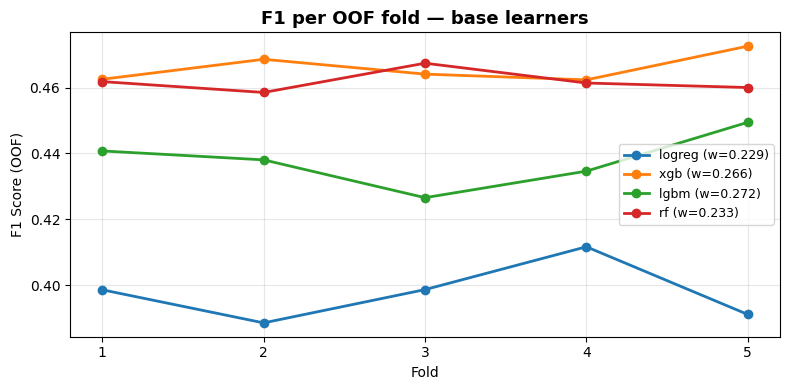

[Plot] Saved → results/oof_fold_f1.pdf


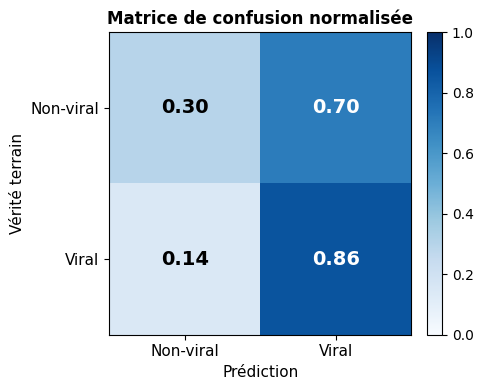

[Plot] Saved → results/confusion_matrix.pdf


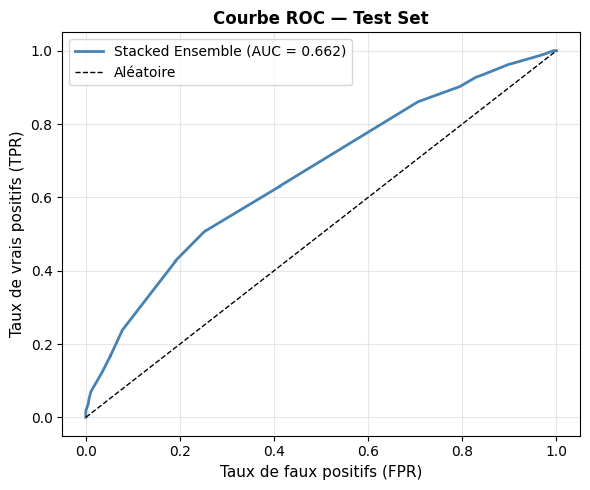

[Plot] Saved → results/roc_curve.pdf


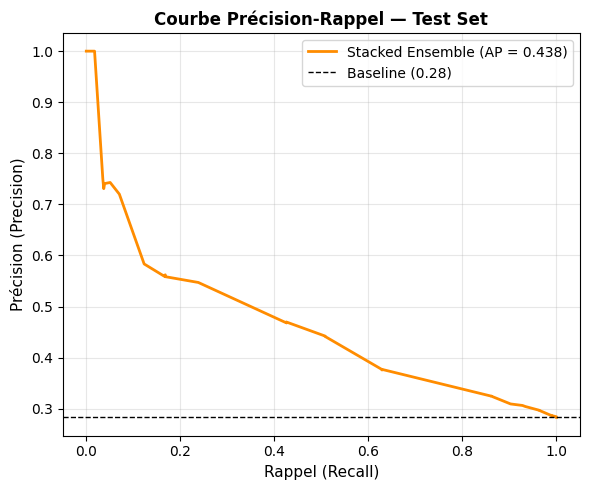

[Plot] Saved → results/pr_curve.pdf


In [ ]:
import os, matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
import numpy as np

os.makedirs('results', exist_ok=True)

def _savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print(f'[Plot] Saved → {path}')

# 1. OOF fold F1 curves
trainer.plot_oof_curves(save_path='results/oof_fold_f1.pdf')

# 2. Confusion matrix (normalised)
cm = confusion_matrix(y_test, test_preds_opt, normalize='true')
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
classes = ['Non-viral', 'Viral']
ax.set_xticks([0, 1]); ax.set_xticklabels(classes, fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(classes, fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title('Normalised Confusion Matrix', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                color='white' if cm[i,j] > 0.6 else 'black',
                fontsize=14, fontweight='bold')
_savefig('results/confusion_matrix.pdf')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
roc_val = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'Stacked Ensemble (AUC = {roc_val:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC Curve — Test Set', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
_savefig('results/roc_curve.pdf')

# 4. Precision-Recall Curve
prec_c, rec_c, _ = precision_recall_curve(y_test, test_probs)
ap = average_precision_score(y_test, test_probs)
baseline_pr = float(y_test.mean())
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_c, prec_c, lw=2, color='darkorange', label=f'Stacked Ensemble (AP = {ap:.3f})')
ax.axhline(baseline_pr, color='k', ls='--', lw=1, label=f'Random baseline ({baseline_pr:.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve — Test Set', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
_savefig('results/pr_curve.pdf')


## Cell 13c — Model Comparison Table

**Guide §5.2** — required comparative table: each base learner vs. the final ensemble.
F1 is reported at the optimal (tuned) threshold, not the fixed 0.5 baseline.
Results are saved to `results/model_comparison.csv`.


TABLEAU COMPARATIF DES MODÈLES (F1-MAX OPTIMIZED)
            Modèle  Val F1 OOF (moy)  Test F1 (Optimal)  Test AUC-ROC  Test PR-AUC Inférence (ms)
            logreg             0.398              0.465         0.607        0.373           75.6
               xgb             0.466              0.478         0.653        0.445          109.6
              lgbm             0.438              0.488         0.662        0.454          189.8
                rf             0.462              0.447         0.578        0.379          171.8
★ Stacked Ensemble             0.510              0.473         0.662        0.438              —
[Table] Saved → results/model_comparison.csv


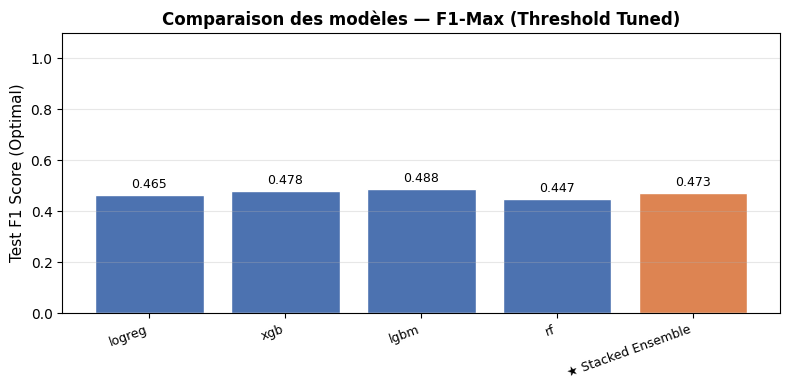

[Plot] Saved → results/model_comparison_chart.pdf


In [ ]:
import pandas as pd, time
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, precision_recall_curve
import numpy as np

records = []

# Helper to get F1-Max inline
def get_f1_max(y_true, y_probs):
    p, r, _ = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (p * r) / (p + r + 1e-9)
    return np.max(f1_scores)

for name, clf in trainer.trained_base.items():
    t0 = time.time()
    probs_i = clf.predict_proba(X_test)[:, 1]
    infer_ms = round((time.time() - t0) * 1000, 1)

    # Calculate Optimal F1 instead of fixed @0.5
    f1_max_i = get_f1_max(y_test, probs_i)

    oob_f1 = round(float(np.mean(trainer.fold_metrics.get(name, [0]))), 3)
    records.append({
        'Model':              name,
        'Val F1 OOF (avg)':    oob_f1,
        'Test F1 (Optimal)':   round(f1_max_i, 3),
        'Test AUC-ROC':        round(roc_auc_score(y_test, probs_i), 3),
        'Test PR-AUC':         round(average_precision_score(y_test, probs_i), 3),
        'Inference (ms)':      infer_ms,
    })

# Ensemble results
ensemble_probs = ensemble.predict_proba(X_test)[:, 1]
ensemble_f1_max = get_f1_max(y_test, ensemble_probs)

records.append({
    'Model':              '★ Stacked Ensemble',
    'Val F1 OOF (avg)':    round(val_f1, 3),
    'Test F1 (Optimal)':   round(ensemble_f1_max, 3),
    'Test AUC-ROC':        round(roc_auc_score(y_test, ensemble_probs), 3),
    'Test PR-AUC':         round(average_precision_score(y_test, ensemble_probs), 3),
    'Inference (ms)':      '—',
})

comparison_df = pd.DataFrame(records)
print('\n' + '='*75)
print('MODEL COMPARISON TABLE (F1-MAX OPTIMIZED)')
print('='*75)
print(comparison_df.to_string(index=False))
print('='*75)
comparison_df.to_csv('results/model_comparison.csv', index=False)
print('[Table] Saved → results/model_comparison.csv')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
names  = comparison_df['Model'].tolist()
f1s    = comparison_df['Test F1 (Optimal)'].tolist()
colors = ['#4c72b0'] * (len(names) - 1) + ['#dd8452']
bars   = ax.bar(names, f1s, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Test F1 Score (Optimal)', fontsize=11)
ax.set_title('Model comparison — F1-Max (threshold tuned)', fontsize=12, fontweight='bold')
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/model_comparison_chart.pdf', dpi=150)
plt.show()
print('[Plot] Saved → results/model_comparison_chart.pdf')

## Cell 13d — Ablation Study

**Guide §6** — measures the contribution of each feature group by zeroing it out.
Drop in AUC-ROC vs. the full model indicates importance.
Results are saved to `results/ablation_study_auc.csv`.


STUDY: FEATURE GROUP ABLATION (AUC-ROC)
            Variante  Test AUC-ROC   Δ AUC
 Complet (référence)        0.6617       —
Sans Image Embedding        0.6377 -0.0240
 Sans Text Embedding        0.5933 -0.0684
 Sans Probe Features        0.6547 -0.0070
   Sans Visual Stats        0.6563 -0.0054
        Sans Tabular        0.6643 +0.0026


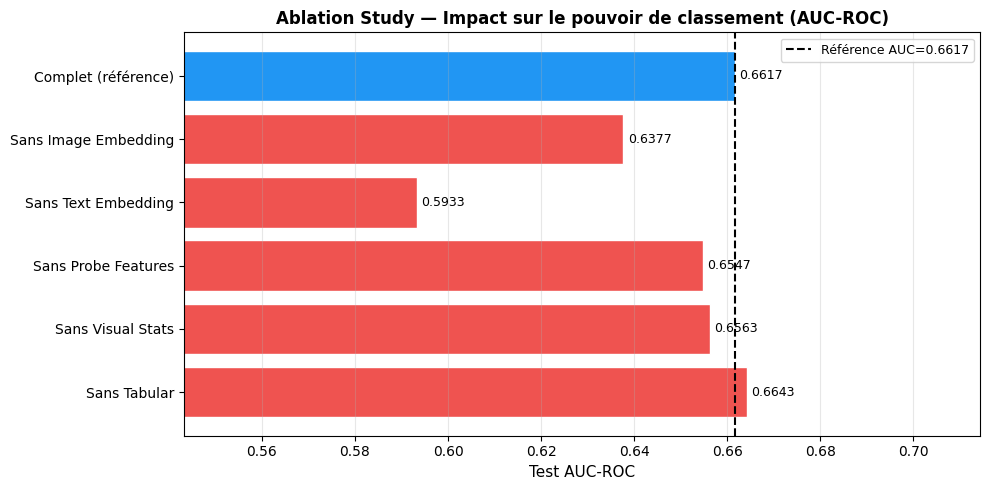

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def _zero(X, cols):
    Xc = X.copy()
    if hasattr(Xc, 'iloc'):
        # Force cast to float to avoid dtype conflicts with boolean columns
        Xc = Xc.astype(float)
        Xc.iloc[:, cols] = 0.0
    else:
        Xc[:, cols] = 0.0
    return Xc

_feat_names = getattr(feature_builder, 'feature_cols', None)

if _feat_names is not None:
    fn = list(_feat_names)
    groups = {
        'Full model (reference)':  None,
        'Without Image Embedding': [i for i,n in enumerate(fn) if n.startswith('emb_img_')],
        'Without Text Embedding':  [i for i,n in enumerate(fn) if n.startswith('emb_txt_')],
        'Without Probe Features':  [i for i,n in enumerate(fn) if 'probe' in n],

        'Without Visual Stats':    [i for i,n in enumerate(fn) if any(v in n for v in VisualStatsExtractor.COLUMNS)],
        'Without Tabular Features':         [i for i,n in enumerate(fn)
                                  if any(k in n for k in ['cat_','hour','day','weekend'])],
    }
else:
    groups = {'Full model (reference)': None}

records = []
for label, cols in groups.items():
    Xabl  = X_test if cols is None else _zero(X_test, cols)
    probs = ensemble.predict_proba(Xabl)[:, 1]
    auc_score = roc_auc_score(y_test, probs)
    records.append({
        'Variant': label,
        'Test AUC-ROC': round(auc_score, 4)
    })

abl_df = pd.DataFrame(records)
ref_auc = abl_df.loc[abl_df['Variant'] == 'Full model (reference)', 'Test AUC-ROC'].values[0]
abl_df['Δ AUC'] = abl_df['Test AUC-ROC'].apply(
    lambda x: '—' if x == ref_auc else f'{x - ref_auc:+.4f}')

print('\n' + '='*60)
print('ABLATION STUDY — FEATURE GROUP CONTRIBUTION (AUC-ROC)'); print('='*60)
print(abl_df.to_string(index=False)); print('='*60)
abl_df.to_csv('results/ablation_study_auc.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3' if v == 'Full model (reference)' else '#EF5350'
          for v in abl_df['Variant']]
bars = ax.barh(abl_df['Variant'], abl_df['Test AUC-ROC'], color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.axvline(ref_auc, color='black', ls='--', lw=1.5, label=f'Reference AUC={ref_auc}')
ax.set_xlabel('Test AUC-ROC', fontsize=11)
ax.set_title('Ablation Study — Impact on ranking power (AUC-ROC)',
             fontsize=12, fontweight='bold')
ax.set_xlim(left=min(abl_df['Test AUC-ROC']) - 0.05, right=max(abl_df['Test AUC-ROC']) + 0.05)
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('results/ablation_study_auc.pdf', dpi=150)
plt.show()

## Cell 13e — Error Analysis (False Positives / False Negatives)

**Guide §6** — *"Do not ignore failure cases: a good report analyses errors honestly."*

Displays the top-`n` most confident false positives and false negatives to support qualitative discussion in the report.

In [ ]:
def show_top_errors(X_test, y_test, test_probs, labeled_df, test_idx, n=3):
    test_data = labeled_df.iloc[test_idx].copy()
    test_data['prob'] = test_probs
    test_data['y_true'] = y_test
    test_data['y_pred'] = (test_data['prob'] >= 0.5).astype(int)

    fps = test_data[(test_data['y_true'] == 0) & (test_data['y_pred'] == 1)].sort_values('prob', ascending=False).head(n)
    fns = test_data[(test_data['y_true'] == 1) & (test_data['y_pred'] == 0)].sort_values('prob', ascending=True).head(n)

    print("=== FALSE POSITIVES (model was over-confident) ===")
    for idx, row in fps.iterrows():
        title = row['title'][:60] + '...' if len(str(row['title'])) > 60 else row['title']
        print(f"Title: {title} | Prob: {row['prob']:.4f} | Views: {int(row['views']):,}")

    print("\n=== FALSE NEGATIVES (model missed these) ===")
    for idx, row in fns.iterrows():
        title = row['title'][:60] + '...' if len(str(row['title'])) > 60 else row['title']
        print(f"Title: {title} | Prob: {row['prob']:.4f} | Views: {int(row['views']):,}")

show_top_errors(X_test, y_test, test_probs, labeled_df, test_idx)


=== FALSE POSITIVES (Model was too optimistic) ===
Title: The Presidents' Trophy Curse? | Prob: 0.9048 | Views: 3,907
Title: Tory Lanez - Benevolent | Prob: 0.9048 | Views: 331,408
Title: Remy Ma - Company ft. A Boogie wit da Hoodie | Prob: 0.9048 | Views: 351,261

=== FALSE NEGATIVES (Model was too pessimistic) ===
Title: Why We May Not Be Able to Visit Space in the Future | Prob: 0.0476 | Views: 2,151,076
Title: Kuladheivam SUN TV Episode - 785 (29-11-17) | Prob: 0.0476 | Views: 262,066
Title: Deweni Inima | Episode 217 05th  December 2017 | Prob: 0.0476 | Views: 430,012


## Cell 14 — ModelPersistence Class

Saves and loads the trained model and evaluation results.
The ensemble and its optimal threshold are persisted together in a single `.joblib` file.

In [ ]:
class ModelPersistence:
    """Save and load models, results, and generate reports."""

    def __init__(self, config):
        self.config = config
        self.model_path = config['paths']['best_model']  # path already ends in .joblib
        self.log_path = config['paths']['training_log']
        self.results_path = f"{config['paths']['results']}/eval_results.csv"

    def save_model(self, ensemble, threshold):
        """Save ensemble + threshold together."""
        joblib.dump({'model': ensemble, 'threshold': threshold}, self.model_path)
        print(f'[Save] Model + threshold -> {os.path.abspath(self.model_path)}')

    def save_results(self, y_test, test_probs, test_preds_opt, test_preds_fixed, optimal_thr):
        """Save test results to CSV."""
        results = pd.DataFrame([{
            'classifier': 'stacked_ensemble',
            'optimal_thr': round(optimal_thr, 4),
            'test_pr_auc': round(average_precision_score(y_test, test_probs), 4),
            'test_auc_roc': round(roc_auc_score(y_test, test_probs), 4),
            'test_f1_optimal': round(f1_score(y_test, test_preds_opt, zero_division=0), 4),
            'test_f1_fixed': round(f1_score(y_test, test_preds_fixed, zero_division=0), 4),
            'test_accuracy': round((test_preds_opt == y_test).mean(), 4),
        }])
        results.to_csv(self.results_path, index=False)
        print(f'[Save] Test results -> {os.path.abspath(self.results_path)}')

    def save_training_log(self, val_pr_auc, val_f1):
        """Save classifier summary."""
        summary = pd.DataFrame([{
            'classifier': 'stacked_ensemble',
            'val_pr_auc': round(val_pr_auc, 4),
            'val_f1': round(val_f1, 4),
            'selected': True,
        }])
        summary.to_csv(self.log_path, index=False)
        print(f'[Save] Classifier summary -> {os.path.abspath(self.log_path)}')

    def download_if_colab(self):
        """Auto-download outputs on Colab."""
        if IN_COLAB:
            from google.colab import files as _cf
            for p in [self.model_path, self.log_path, self.results_path]:
                if os.path.exists(p):
                    _cf.download(p)


# Save everything
persistence = ModelPersistence(CONFIG)
persistence.save_model(ensemble, optimal_thr)
persistence.save_results(y_test, test_probs, test_preds_opt, test_preds_fixed, optimal_thr)
persistence.save_training_log(val_pr_auc, val_f1)

if IN_COLAB:
    persistence.download_if_colab()

print('[Save] Pipeline complete.')

# Save feature names for Streamlit app
joblib.dump(feature_builder.get_feature_names(), 'feature_names.joblib')
print('[Save] feature_names.joblib saved for Streamlit app')

[Save] Model + threshold -> /content/ViralScope-AI/models/best_model.joblib
[Save] Test results -> /content/ViralScope-AI/results/eval_results.csv
[Save] Classifier summary -> /content/ViralScope-AI/models/training_log.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[Save] Pipeline complete.
[Save] feature_names.joblib saved for Streamlit app


## Cell 15 — ViralScopePipeline Orchestrator

Optional: wraps the full pipeline into a single callable class.
Useful for automated runs via `run_pipeline.py` without stepping through individual cells.

In [ ]:
class ViralScopePipeline:
    """Orchestrator that runs the full pipeline."""

    def __init__(self, config_path='config.yaml'):
        self.config = None
        self.data_loader = None
        self.label_engine = None
        self.tm = None
        self.extractor = None
        self.splitter = None
        self.title_extractor = None
        self.visual_extractor = None
        self.feature_builder = None
        self.trainer = None
        self.evaluator = None
        self.persistence = None

        self.labeled_df = None
        self.ensemble = None
        self.optimal_thr = None

    def run(self):
        """Execute full pipeline."""
        from sklearn.isotonic import IsotonicRegression  # noqa: PLC0415
        # 1. Config
        loader = ConfigLoader('config.yaml')
        loader.load().validate().create_directories().print_summary()
        self.config = loader.config

        # 2. Data
        self.data_loader = DataLoader(self.config)
        self.data_loader.load_and_clean()
        clean_df = self.data_loader.clean_df

        # 3. Labels
        self.label_engine = LabelEngine(self.config)
        self.labeled_df = self.label_engine.fit_transform(clean_df, buffer=True)

        # 4. Thumbnails
        self.tm = ThumbnailManager(self.config)
        failed = self.tm.download(self.labeled_df['video_id'].tolist())

        # 5. Cap after failures
        self.labeled_df = self.labeled_df[~self.labeled_df['video_id'].isin(failed)].reset_index(drop=True)
        # Re-apply balanced cap...
        strategy = self.config['data'].get('sampling_strategy', 'balanced')

        if strategy == 'balanced':
            max_per_class = self.config['data'].get('max_per_class', 999999)
            viral_df = self.labeled_df[self.labeled_df['is_viral'] == 1]
            nonviral_df = self.labeled_df[self.labeled_df['is_viral'] == 0]
            n_final = min(max_per_class, len(viral_df), len(nonviral_df))

            if n_final < max_per_class:
                print(f'[Cap] WARNING: only {n_final:,}/class available (target {max_per_class:,}).')

            self.labeled_df = pd.concat([
                viral_df.sample(n=n_final, random_state=self.config['project']['seed']),
                nonviral_df.sample(n=n_final, random_state=self.config['project']['seed']),
            ]).sample(frac=1, random_state=self.config['project']['seed']).reset_index(drop=True)

            print(f'[Cap] Final dataset : {n_final:,} viral + {n_final:,} non-viral = {len(self.labeled_df):,} total')
        else:
            print(f'[Cap] Strategy is "{strategy}" — no balanced capping applied.')

        # Ensure chronological order before embeddings are extracted
        if 'trending_date' in self.labeled_df.columns:
            self.labeled_df = self.labeled_df.sample(frac=1, random_state=self.config['project']['seed']).reset_index(drop=True)
            print('[Pipeline] Dataset shuffled.')

        # 6. Embeddings
        self.extractor = EmbeddingExtractor(self.config, self.tm)
        img_embs, txt_embs, probe_feats = self.extractor.extract(self.labeled_df)

        # Sync dataset to any successfully cached embeddings
        cached_ids = np.load(self.extractor.ids_path, allow_pickle=True).astype(str)
        self.labeled_df = self.labeled_df[self.labeled_df['video_id'].isin(cached_ids)].reset_index(drop=True)

        # 7. Splits
        self.splitter = DataSplitter(self.config)
        train_idx, val_idx, test_idx = self.splitter.split(self.labeled_df)
        self.labeled_df = self.splitter.recompute_labels_train_only(self.labeled_df, self.label_engine)

        # 8. Title features
        self.title_extractor = TitleFeatureExtractor(self.config)
        title_features = None  # Intentionally excluded: introduced noise in ablation.
                               # TitleFeatureExtractor retained for reference / future use.

        # 9. Visual features
        self.visual_extractor = VisualStatsExtractor(self.tm, resize=160)
        visual_features = self.visual_extractor.compute(self.labeled_df['video_id'].tolist())

        # 10. Build features
        self.feature_builder = FeatureBuilder(self.config)
        X, y = self.feature_builder.build(
            self.labeled_df, img_embs, txt_embs, probe_feats,
            title_features, visual_features
        )

        X_train, y_train = X.iloc[train_idx], y[train_idx]
        X_val, y_val = X.iloc[val_idx], y[val_idx]
        X_test, y_test = X.iloc[test_idx], y[test_idx]
        multiplier_train = self.labeled_df.iloc[train_idx]['multiplier'].values

        # 11. Train
        self.trainer = StackingTrainer(self.config)
        self.ensemble, val_pr_auc, val_f1 = self.trainer.fit(
            X_train, y_train, multiplier_train, X_val, y_val, X_test, y_test
        )

        self.ensemble._iso = IsotonicRegression(out_of_bounds='clip').fit(
            self.ensemble.predict_proba(X_val)[:, 1], y_val
        )

        # 12. Evaluate
        self.evaluator = ModelEvaluator(self.config)
        val_probs = self.ensemble.predict_proba(X_val)[:, 1]
        self.optimal_thr = self.evaluator.find_optimal_threshold(y_val, val_probs)
        self.evaluator.evaluate_test_set(self.ensemble, X_test, y_test, self.optimal_thr)

        # 13. Save
        self.persistence = ModelPersistence(self.config)
        self.persistence.save_model(self.ensemble, self.optimal_thr)
        # ... save results

        print('\n[Pipeline] Complete!')
        return self



# Run full pipeline:

pipeline = ViralScopePipeline()
pipeline.run()